# Tiny GPT dengan Mini Corpus — Tema **Gaming / FPS** 🎮

**Proyek Data Mining ST167 — Modul 9: Membangun Tiny GPT dengan Mini Corpus**
Fakultas Ilmu Komputer, Universitas Amikom Yogyakarta.

Notebook ini membangun sebuah **GPT (Transformer decoder-only)** dari nol dan melatihnya di atas
korpus teks berbahasa Indonesia bertema **gaming, khususnya FPS** (**±18.500 kata**). Ini adalah **versi
SCALE-UP** dari tugas Tiny GPT: model & korpus dibesarkan agar hasilnya lebih baik. Sesuai instruksi tugas:

1. **Korpus** ≥ 2.000 kata (di sini **±18.500 kata**), bebas domain — dipilih tema gaming (khususnya FPS).
2. **Melatih** model GPT dengan korpus tersebut.
3. **Mencoba beberapa mode tokenisasi**: `char`, `word`, `bpe` (implementasi sendiri), dan
   `spm` (SentencePiece, sesuai prasyarat modul `pip install torch sentencepiece`).
4. **Menampilkan hasil + analisis performa** (tabel metrik, kurva loss, perpleksitas, bits/char,
   serta contoh teks hasil generate).

**Skala model:** `embed=256, layers=6, heads=8, konteks=128` (~5–6 juta parameter), dilatih
**4.000 iterasi** dengan **warmup + cosine LR schedule**, sampling **top_p (nucleus) + repetition
penalty**. Seluruh pelatihan dijalankan di **GPU (CUDA)**. Log pelatihan tampil langsung di output
setiap sel sehingga proses belajar model dapat diamati iterasi demi iterasi.

## 1. Setup & Deteksi GPU

In [1]:
import os, io, re, math, time, json, copy, pickle, collections
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib
import matplotlib.pyplot as plt

SEED = 1337
torch.manual_seed(SEED)

# ---- Pilih perangkat: GPU (CUDA) jika tersedia, kalau tidak CPU ----
device = "cuda" if torch.cuda.is_available() else "cpu"

print("="*64)
print("KONFIGURASI LINGKUNGAN")
print("="*64)
print("PyTorch        :", torch.__version__)
print("CUDA tersedia  :", torch.cuda.is_available())
if device == "cuda":
    cap = torch.cuda.get_device_capability(0)
    print("GPU            :", torch.cuda.get_device_name(0))
    print("Compute capab. : sm_%d%d" % (cap[0], cap[1]))
    print("Memori GPU     : %.1f GB" % (torch.cuda.get_device_properties(0).total_memory/1e9))
    # optimasi matmul utk GPU modern
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
print("Perangkat dipakai :", device.upper())
OUT = os.path.join(os.getcwd(), "outputs"); os.makedirs(OUT, exist_ok=True)
print("Folder output  :", OUT)

KONFIGURASI LINGKUNGAN
PyTorch        : 2.11.0+cu128
CUDA tersedia  : True
GPU            : NVIDIA GeForce RTX 5060 Laptop GPU
Compute capab. : sm_120
Memori GPU     : 8.5 GB
Perangkat dipakai : CUDA
Folder output  : C:\Users\LENOVO\Documents\Claude\tinygpt_gaming\outputs


## 2. Korpus Gaming / FPS

Korpus dibaca dari `corpus_gaming.txt`. Kita pisahkan 90% awal untuk **train** dan 10% akhir untuk
**validasi**. Jumlah karakter validasi (`VAL_CHARS`) dipakai sebagai penyebut tetap saat menghitung
**bits/char**, agar metrik adil dan **sebanding antar-mode tokenisasi**.

In [2]:
with io.open("corpus_gaming.txt", encoding="utf-8") as f:
    raw = f.read()

n_words = len(raw.split())
n_chars = len(raw)
n_uniq  = len(set(raw))
cut = int(0.9 * len(raw))
train_text, val_text = raw[:cut], raw[cut:]
VAL_CHARS = len(val_text)

print("Jumlah kata         :", n_words)
print("Jumlah karakter     :", n_chars)
print("Karakter unik       :", n_uniq)
print("Train (char)        :", len(train_text))
print("Validasi (char)     :", len(val_text))
print("\n--- Cuplikan korpus (300 char pertama) ---\n")
print(raw[:300] + " ...")

Jumlah kata         : 18464
Jumlah karakter     : 139732
Karakter unik       : 55
Train (char)        : 125758
Validasi (char)     : 13974

--- Cuplikan korpus (300 char pertama) ---

Video game adalah salah satu bentuk hiburan paling populer di dunia modern yang dimainkan oleh miliaran orang dari berbagai usia. Permainan elektronik ini menggabungkan teknologi, seni, cerita, dan interaksi sehingga menciptakan pengalaman yang sangat menarik. Seorang pemain dapat menjelajahi dunia  ...


## 3. Tokenisasi — Empat Mode

Tokenisasi mengubah teks menjadi deret angka (token id) yang bisa diproses model. Kita bandingkan
empat pendekatan:

| Mode | Unit token | Karakteristik |
|------|-----------|----------------|
| `char` | per karakter | vocab sangat kecil, urutan token panjang |
| `word` | per kata | vocab besar, urutan pendek, rentan OOV (`<unk>`) |
| `bpe`  | subword Byte-Pair Encoding (implementasi sendiri) | kompromi vocab vs panjang |
| `spm`  | SentencePiece BPE (library) | subword standar industri |

In [3]:
class CharTokenizer:
    name = "char"
    def fit(self, full_text):
        chars = sorted(set(full_text))
        self.stoi = {c: i for i, c in enumerate(chars)}
        self.itos = {i: c for c, i in self.stoi.items()}
        self.vocab_size = len(chars)
        return self
    def encode(self, s): return [self.stoi[c] for c in s if c in self.stoi]
    def decode(self, ids): return "".join(self.itos[i] for i in ids)

class WordTokenizer:
    name = "word"
    pat = re.compile(r"[a-zA-Z]+|[^a-zA-Z\s]|\s+")
    def _split(self, s): return [t for t in self.pat.findall(s.lower())]
    def fit(self, train_text):
        toks = self._split(train_text)
        vocab = ["<unk>"] + sorted(set(toks))
        self.stoi = {t: i for i, t in enumerate(vocab)}
        self.itos = {i: t for t, i in self.stoi.items()}
        self.vocab_size = len(vocab)
        return self
    def encode(self, s): return [self.stoi.get(t, 0) for t in self._split(s)]
    def decode(self, ids): return "".join(self.itos[i] for i in ids)

class BPETokenizer:
    name = "bpe"
    def __init__(self, num_merges=250): self.num_merges = num_merges
    def fit(self, train_text, full_text=None):
        words = re.findall(r"[a-zA-Z]+", train_text.lower())
        vocab = collections.Counter(" ".join(list(w)) + " </w>" for w in words)
        merges = []
        for _ in range(self.num_merges):
            pairs = collections.Counter()
            for word, fr in vocab.items():
                sym = word.split()
                for j in range(len(sym) - 1):
                    pairs[(sym[j], sym[j + 1])] += fr
            if not pairs: break
            best = max(pairs, key=pairs.get); merges.append(best)
            patt = re.compile(r"(?<!\S)" + re.escape(" ".join(best)) + r"(?!\S)")
            vocab = {patt.sub("".join(best), w): fr for w, fr in vocab.items()}
        self.ranks = {p: i for i, p in enumerate(merges)}
        units = set()
        for w in re.findall(r"[a-zA-Z]+", (full_text or train_text).lower()):
            units.update(self._enc_word(w))
        base = set(ch for ch in (full_text or train_text).lower())
        vocab_list = ["<unk>", " "] + sorted(units | base | {"</w>"})
        self.stoi = {t: i for i, t in enumerate(dict.fromkeys(vocab_list))}
        self.itos = {i: t for t, i in self.stoi.items()}
        self.vocab_size = len(self.stoi)
        return self
    def _enc_word(self, word):
        sym = list(word) + ["</w>"]
        while len(sym) > 1:
            best, br = None, None
            for i in range(len(sym) - 1):
                r = self.ranks.get((sym[i], sym[i + 1]))
                if r is not None and (br is None or r < br): br, best = r, (sym[i], sym[i + 1])
            if best is None: break
            merged, i = [], 0
            while i < len(sym):
                if i < len(sym) - 1 and (sym[i], sym[i + 1]) == best:
                    merged.append(sym[i] + sym[i + 1]); i += 2
                else: merged.append(sym[i]); i += 1
            sym = merged
        return sym
    def encode(self, s):
        ids = []
        for tok in re.findall(r"[a-zA-Z]+|\s+|[^a-zA-Z\s]", s.lower()):
            if tok.isspace(): ids.append(self.stoi.get(" ", 0))
            elif tok.isalpha():
                for u in self._enc_word(tok): ids.append(self.stoi.get(u, 0))
            else: ids.append(self.stoi.get(tok, 0))
        return ids
    def decode(self, ids):
        return "".join(self.itos.get(i, "") for i in ids).replace("</w>", " ")

class SPMTokenizer:
    name = "spm"
    def __init__(self, vocab_size=220): self.req = vocab_size
    def fit(self, train_text, full_text=None):
        import sentencepiece as spm
        tmp = os.path.join(OUT, "_spm_train.txt")
        io.open(tmp, "w", encoding="utf-8").write(train_text)
        prefix = os.path.join(OUT, "spm_gaming")
        last_err = None
        for vs in [self.req, 200, 160, 120, 90, 64]:
            try:
                spm.SentencePieceTrainer.train(
                    input=tmp, model_prefix=prefix, vocab_size=vs,
                    model_type="bpe", character_coverage=1.0,
                    bos_id=-1, eos_id=-1, unk_id=0, pad_id=-1)
                break
            except Exception as e:
                last_err = e
        else:
            raise last_err
        self.model_path = prefix + ".model"
        self.sp = spm.SentencePieceProcessor(model_file=self.model_path)
        self.vocab_size = self.sp.get_piece_size()
        return self
    def encode(self, s): return self.sp.encode(s, out_type=int)
    def decode(self, ids): return self.sp.decode(ids)

print("4 kelas tokenizer siap: char, word, bpe, spm")

4 kelas tokenizer siap: char, word, bpe, spm


In [4]:
# --- fit semua tokenizer & bandingkan ---
tokenizers = [
    CharTokenizer().fit(raw),
    WordTokenizer().fit(train_text),
    BPETokenizer(num_merges=250).fit(train_text, full_text=raw),
]
try:
    tokenizers.append(SPMTokenizer(vocab_size=220).fit(train_text, full_text=raw))
except Exception as e:
    print("  [spm dilewati]:", e)

sample_txt = "game first person shooter"
print(f"{'mode':<6}{'vocab':>8}{'n_tok(train)':>14}{'n_tok(val)':>12}   contoh encode '%s'" % sample_txt)
print("-"*70)
for tk in tokenizers:
    ntr = len(tk.encode(train_text)); nva = len(tk.encode(val_text))
    enc = tk.encode(sample_txt)
    print(f"{tk.name:<6}{tk.vocab_size:>8}{ntr:>14}{nva:>12}   {enc[:10]}{' ...' if len(enc)>10 else ''}")

print("\nUji bolak-balik (encode -> decode) mode bpe:")
_bpe = [t for t in tokenizers if t.name=='bpe'][0]
print("  asli :", sample_txt)
print("  hasil:", _bpe.decode(_bpe.encode(sample_txt)))

mode     vocab  n_tok(train)  n_tok(val)   contoh encode 'game first person shooter'
----------------------------------------------------------------------
char        55        125758       13974   [35, 29, 41, 33, 1, 34, 37, 46, 47, 48] ...
word      1952         35122        3913   [501, 2, 484, 2, 1442, 2, 1696]
bpe        275         62338        6871   [116, 1, 109, 142, 232, 7, 1, 203, 219, 192] ...


spm        220         53188        5780   [77, 165, 119, 176, 173, 27, 176, 47, 12, 183] ...

Uji bolak-balik (encode -> decode) mode bpe:
  asli : game first person shooter
  hasil: game  first  person  shooter 


## 4. Arsitektur Tiny GPT

Model adalah **Transformer decoder-only** (gaya GPT) yang ringkas: *token embedding* +
*positional embedding* → beberapa **Block** (Multi-Head Self-Attention bertopeng kausal +
FeedForward, dengan residual & LayerNorm) → *LayerNorm* akhir → *linear head* ke ukuran vocab.

Attention memakai `F.scaled_dot_product_attention` (kernel cepat / flash-attention di GPU) dengan
`is_causal=True` sehingga tiap token hanya boleh melihat token sebelumnya.

In [5]:
# ----------------- HYPERPARAMETER (versi SCALE-UP) -----------------
BLOCK_SIZE    = 128    # panjang konteks (4x lebih panjang dari versi tiny)
EMBED_DIM     = 256
N_HEADS       = 8
N_LAYERS      = 6
DROPOUT       = 0.2    # regularisasi
BATCH_SIZE    = 48
LR            = 1e-3   # lr puncak (dengan warmup + cosine decay)
LR_MIN        = 1e-4   # lr minimum di akhir cosine
WARMUP_ITERS  = 200    # naikkan lr bertahap di awal
MAX_ITERS     = 4000
EVAL_INTERVAL = 200
EVAL_ITERS    = 40
WEIGHT_DECAY  = 0.1    # regularisasi AdamW
EARLY_STOP    = True   # ambil checkpoint val-terbaik

class CausalSelfAttention(nn.Module):
    def __init__(self, embed_dim, n_heads, dropout):
        super().__init__()
        assert embed_dim % n_heads == 0
        self.qkv = nn.Linear(embed_dim, 3*embed_dim, bias=False)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.resid_drop = nn.Dropout(dropout)
        self.n_heads = n_heads; self.head_dim = embed_dim // n_heads; self.dropout = dropout
    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True,
                                           dropout_p=self.dropout if self.training else 0.0)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.proj(y))

class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4*n_embd), nn.ReLU(),
            nn.Linear(4*n_embd, n_embd), nn.Dropout(dropout))
    def forward(self, x): return self.net(x)

class Block(nn.Module):
    def __init__(self, embed_dim, n_heads, dropout):
        super().__init__()
        self.sa = CausalSelfAttention(embed_dim, n_heads, dropout)
        self.ffwd = FeedForward(embed_dim, dropout)
        self.ln1 = nn.LayerNorm(embed_dim); self.ln2 = nn.LayerNorm(embed_dim)
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class TinyGPT(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, EMBED_DIM)
        self.pos_emb = nn.Embedding(BLOCK_SIZE, EMBED_DIM)
        self.blocks = nn.Sequential(*[Block(EMBED_DIM, N_HEADS, DROPOUT) for _ in range(N_LAYERS)])
        self.ln_f = nn.LayerNorm(EMBED_DIM)
        self.lm_head = nn.Linear(EMBED_DIM, vocab_size)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.tok_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=idx.device))
        x = self.blocks(tok + pos)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            B, T, V = logits.shape
            loss = F.cross_entropy(logits.view(B*T, V), targets.view(B*T))
        return logits, loss
    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=0.8, top_k=None,
                 top_p=0.9, repetition_penalty=1.3):
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -BLOCK_SIZE:])
            logits = logits[:, -1, :]
            # repetition penalty: kurangi peluang token yang sudah muncul (anti "dan dan dan")
            if repetition_penalty and repetition_penalty != 1.0:
                for b in range(idx.size(0)):
                    seen = torch.unique(idx[b])
                    sc = logits[b, seen]
                    logits[b, seen] = torch.where(sc > 0, sc / repetition_penalty,
                                                  sc * repetition_penalty)
            logits = logits / temperature
            if top_k:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float("inf")
            if top_p and top_p < 1.0:                    # nucleus sampling
                s_logits, s_idx = torch.sort(logits, descending=True, dim=-1)
                cum = torch.cumsum(F.softmax(s_logits, dim=-1), dim=-1)
                drop = cum > top_p
                drop[..., 1:] = drop[..., :-1].clone(); drop[..., 0] = False
                for b in range(logits.size(0)):
                    logits[b, s_idx[b, drop[b]]] = -float("inf")
            probs = F.softmax(logits, dim=-1)
            nxt = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, nxt], dim=1)
        return idx

print("Arsitektur TinyGPT siap.")
print(f"Hyperparam: block={BLOCK_SIZE} embed={EMBED_DIM} heads={N_HEADS} layers={N_LAYERS} "
      f"dropout={DROPOUT} wd={WEIGHT_DECAY} iters={MAX_ITERS} lr={LR} early_stop={EARLY_STOP}")

Arsitektur TinyGPT siap.
Hyperparam: block=128 embed=256 heads=8 layers=6 dropout=0.2 wd=0.1 iters=4000 lr=0.001 early_stop=True


## 5. Pelatihan

Untuk setiap mode tokenisasi: encode korpus → bangun batch acak → latih `MAX_ITERS` iterasi.
Setiap `EVAL_INTERVAL` iterasi, kita ukur train/val loss dan menyimpan **checkpoint val-terbaik**
(early stopping). **Log tampil langsung di bawah** sehingga proses belajar terlihat jelas.

In [6]:
def make_batches(data, n):
    ix = torch.randint(len(data) - BLOCK_SIZE - 1, (n,))
    x = torch.stack([data[i:i+BLOCK_SIZE] for i in ix])
    y = torch.stack([data[i+1:i+BLOCK_SIZE+1] for i in ix])
    return x.to(device), y.to(device)

def lr_at(it):
    """Jadwal learning rate: warmup linear lalu cosine decay ke LR_MIN."""
    if it < WARMUP_ITERS:
        return LR * (it + 1) / WARMUP_ITERS
    prog = (it - WARMUP_ITERS) / max(1, MAX_ITERS - WARMUP_ITERS)
    return LR_MIN + 0.5 * (LR - LR_MIN) * (1 + math.cos(math.pi * min(1.0, prog)))

@torch.no_grad()
def estimate(model, splits):
    model.eval(); out = {}
    for name, data in splits.items():
        losses = torch.zeros(EVAL_ITERS)
        for kk in range(EVAL_ITERS):
            xb, yb = make_batches(data, BATCH_SIZE)
            _, loss = model(xb, yb); losses[kk] = loss.item()
        out[name] = losses.mean().item()
    model.train(); return out

def run_mode(tok, seed_text="game fps "):
    t0 = time.time()
    train_ids = torch.tensor(tok.encode(train_text), dtype=torch.long)
    val_ids   = torch.tensor(tok.encode(val_text),   dtype=torch.long)
    splits = {"train": train_ids, "val": val_ids}
    model = TinyGPT(tok.vocab_size).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    print(f"  vocab={tok.vocab_size} | params={n_params:,} | "
          f"train_tok={len(train_ids):,} | val_tok={len(val_ids):,}")
    history = []
    best_val, best_iter, best_state = float("inf"), 0, None
    for it in range(MAX_ITERS + 1):
        lr_now = lr_at(it)
        for g in opt.param_groups: g["lr"] = lr_now
        if it % EVAL_INTERVAL == 0:
            est = estimate(model, splits)
            history.append((it, est["train"], est["val"]))
            flag = ""
            if est["val"] < best_val:
                best_val, best_iter = est["val"], it
                best_state = copy.deepcopy(model.state_dict()); flag = "  <- best"
            print(f"    iter {it:4d} | lr {lr_now:.2e} | train {est['train']:.4f} | "
                  f"val {est['val']:.4f}{flag}")
        xb, yb = make_batches(train_ids, BATCH_SIZE)
        _, loss = model(xb, yb)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    est = estimate(model, splits)
    val_loss, train_loss = est["val"], est["train"]
    ppl_fin = math.exp(val_loss)
    bpc_fin = (val_loss * len(val_ids) / math.log(2)) / VAL_CHARS

    def gen_from(m):
        ctx = torch.tensor([tok.encode(seed_text) or [0]], dtype=torch.long, device=device)
        return tok.decode(m.generate(ctx, 200)[0].tolist())

    sample_fin = gen_from(model)
    best_ppl = math.exp(best_val)
    best_bpc = (best_val * len(val_ids) / math.log(2)) / VAL_CHARS
    # simpan model FINAL -> ke memori (sel "coba sendiri") & ke disk (generate.py)
    MODELS[tok.name] = model
    TOKS[tok.name] = tok
    torch.save(model.state_dict(), os.path.join(OUT, f"ckpt_{tok.name}.pt"))
    # sampel early-stop dihitung dari salinan terpisah agar model demo tetap versi final
    sample_best = None
    if EARLY_STOP and best_state is not None:
        mtmp = TinyGPT(tok.vocab_size).to(device); mtmp.load_state_dict(best_state)
        sample_best = gen_from(mtmp)
    sec = time.time() - t0
    print(f"  selesai {sec:.1f}s | val_best={best_val:.4f}@{best_iter} | "
          f"PPL_best={best_ppl:.1f} | bpc_best={best_bpc:.3f}")
    return dict(mode=tok.name, vocab_size=tok.vocab_size, params=n_params,
                n_train_tok=len(train_ids), n_val_tok=len(val_ids),
                train_loss=train_loss, val_loss=val_loss,
                ppl_fin=ppl_fin, bpc_fin=bpc_fin,
                best_val=best_val, best_iter=best_iter,
                best_ppl=best_ppl, best_bpc=best_bpc,
                history=history, sample_fin=sample_fin, sample_best=sample_best, sec=sec)

MODELS, TOKS = {}, {}   # diisi run_mode: nama_mode -> (model terlatih, tokenizer)
print("Fungsi pelatihan siap.")

Fungsi pelatihan siap.


In [7]:
results = []
for tok in tokenizers:
    print("="*64)
    print(f"MODE TOKENISASI: {tok.name.upper()}")
    print("="*64)
    results.append(run_mode(tok))
    print()
print(">>> Semua mode selesai dilatih.")

MODE TOKENISASI: CHAR


  vocab=55 | params=4,795,447 | train_tok=125,758 | val_tok=13,974


    iter    0 | lr 5.00e-06 | train 4.2404 | val 4.2337  <- best


    iter  200 | lr 1.00e-03 | train 2.0643 | val 2.0398  <- best


    iter  400 | lr 9.94e-04 | train 1.3293 | val 1.3659  <- best


...

    iter 3400 | lr 1.54e-04 | train 0.0715 | val 4.3301


    iter 3600 | lr 1.24e-04 | train 0.0709 | val 4.3038


    iter 3800 | lr 1.06e-04 | train 0.0698 | val 4.3508


    iter 4000 | lr 1.00e-04 | train 0.0691 | val 4.3283


  selesai 145.4s | val_best=2.4687@400 | PPL_best=11.8 | bpc_best=1.473

>>> Semua mode selesai dilatih.


## 6. Hasil & Perbandingan

- **PPL_fin / PPL_best** = perpleksitas pada akhir 1500 iter vs pada checkpoint val-terbaik (early stop).
- **bpc_best** = *bits per character* dinormalisasi ke jumlah karakter validasi yang **sama** untuk
  semua mode → satu-satunya metrik yang benar-benar **sebanding antar-mode**.

In [8]:
hdr = (f"{'mode':<6}{'vocab':>7}{'params':>9}{'valTok':>8}"
       f"{'trainL':>8}{'valL_fin':>9}{'PPL_fin':>9}"
       f"{'valL_best':>10}{'@iter':>6}{'PPL_best':>9}{'bpc_best':>9}{'sec':>7}")
print(hdr); print("-"*len(hdr))
for r in results:
    print(f"{r['mode']:<6}{r['vocab_size']:>7}{r['params']:>9}{r['n_val_tok']:>8}"
          f"{r['train_loss']:>8.3f}{r['val_loss']:>9.3f}{r['ppl_fin']:>9.1f}"
          f"{r['best_val']:>10.3f}{r['best_iter']:>6}{r['best_ppl']:>9.1f}"
          f"{r['best_bpc']:>9.3f}{r['sec']:>7.1f}")

# simpan ringkasan ke JSON
with io.open(os.path.join(OUT, "hasil_gaming.json"), "w", encoding="utf-8") as f:
    json.dump([{k: v for k, v in r.items() if k != "history"} for r in results],
              f, ensure_ascii=False, indent=2)
print("\nRingkasan disimpan ke outputs/hasil_gaming.json")

mode    vocab   params  valTok  trainL valL_fin  PPL_fin valL_best @iter PPL_best bpc_best    sec
-------------------------------------------------------------------------------------------------
char       55  4795447   13974   0.172    1.363      3.9     1.020  1200      2.8    1.472  592.9
word     1952  5768608    3913   0.062    4.271     71.6     2.762   600     15.8    1.116  161.4
bpe       275  4908307    6871   0.077    3.262     26.1     2.039   600      7.7    1.447  146.0
spm       220  4880092    5780   0.069    4.378     79.6     2.469   400     11.8    1.473  145.4

Ringkasan disimpan ke outputs/hasil_gaming.json


## 7. Visualisasi

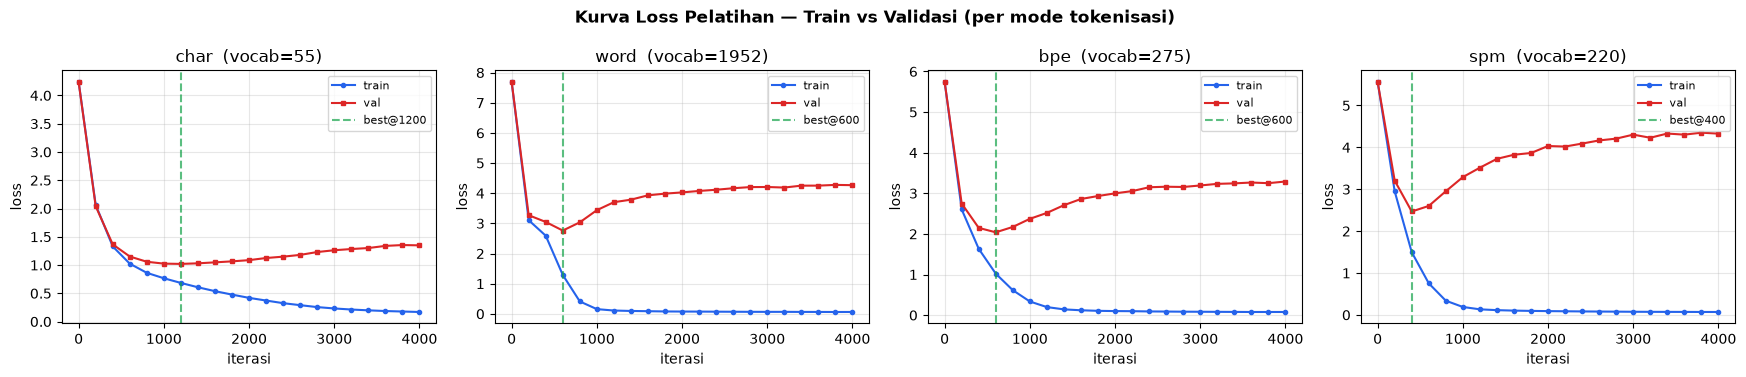

In [9]:
# ---- Chart 1: Kurva loss train vs val per mode ----
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(4.4*n, 3.8), squeeze=False)
for ax, r in zip(axes[0], results):
    its = [h[0] for h in r["history"]]
    tr  = [h[1] for h in r["history"]]
    va  = [h[2] for h in r["history"]]
    ax.plot(its, tr, "-o", ms=3, label="train", color="#2563eb")
    ax.plot(its, va, "-s", ms=3, label="val", color="#dc2626")
    ax.axvline(r["best_iter"], ls="--", color="#16a34a", alpha=.7, label=f"best@{r['best_iter']}")
    ax.set_title(f"{r['mode']}  (vocab={r['vocab_size']})")
    ax.set_xlabel("iterasi"); ax.set_ylabel("loss"); ax.grid(alpha=.3); ax.legend(fontsize=8)
fig.suptitle("Kurva Loss Pelatihan — Train vs Validasi (per mode tokenisasi)", fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUT, "chart_loss_curves.png"), dpi=120, bbox_inches="tight")
plt.show()

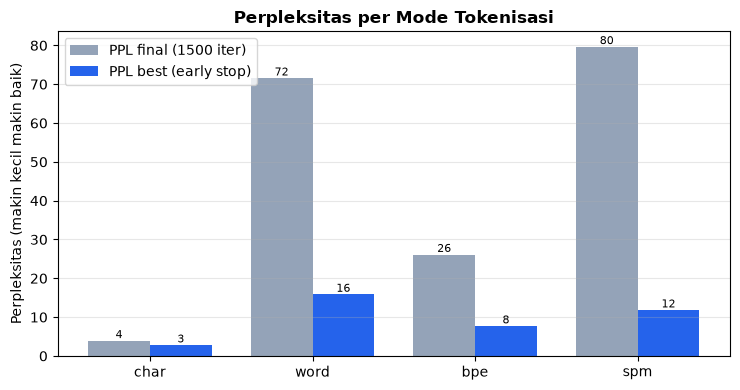

In [10]:
# ---- Chart 2: Perbandingan Perpleksitas (final vs best) ----
import numpy as np
modes = [r["mode"] for r in results]
x = np.arange(len(modes)); w = 0.38
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(x - w/2, [r["ppl_fin"]  for r in results], w, label="PPL final (1500 iter)", color="#94a3b8")
ax.bar(x + w/2, [r["best_ppl"] for r in results], w, label="PPL best (early stop)", color="#2563eb")
for i, r in enumerate(results):
    ax.text(i - w/2, r["ppl_fin"],  f"{r['ppl_fin']:.0f}",  ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, r["best_ppl"], f"{r['best_ppl']:.0f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(modes); ax.set_ylabel("Perpleksitas (makin kecil makin baik)")
ax.set_title("Perpleksitas per Mode Tokenisasi", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=.3)
fig.tight_layout(); fig.savefig(os.path.join(OUT, "chart_ppl.png"), dpi=120, bbox_inches="tight")
plt.show()

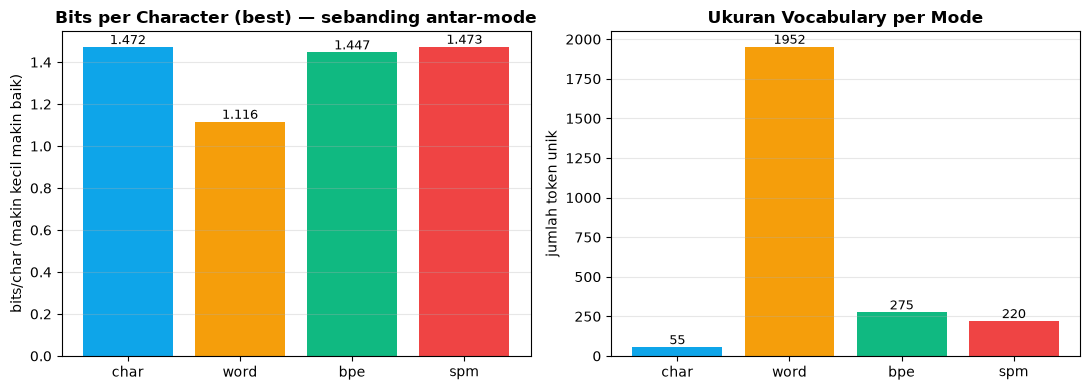

In [11]:
# ---- Chart 3: bits/char (sebanding antar-mode) & ukuran vocab ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
colors = ["#0ea5e9", "#f59e0b", "#10b981", "#ef4444"][:len(results)]
ax1.bar(modes, [r["best_bpc"] for r in results], color=colors)
for i, r in enumerate(results):
    ax1.text(i, r["best_bpc"], f"{r['best_bpc']:.3f}", ha="center", va="bottom", fontsize=9)
ax1.set_title("Bits per Character (best) — sebanding antar-mode", fontweight="bold")
ax1.set_ylabel("bits/char (makin kecil makin baik)"); ax1.grid(axis="y", alpha=.3)

ax2.bar(modes, [r["vocab_size"] for r in results], color=colors)
for i, r in enumerate(results):
    ax2.text(i, r["vocab_size"], str(r["vocab_size"]), ha="center", va="bottom", fontsize=9)
ax2.set_title("Ukuran Vocabulary per Mode", fontweight="bold")
ax2.set_ylabel("jumlah token unik"); ax2.grid(axis="y", alpha=.3)
fig.tight_layout(); fig.savefig(os.path.join(OUT, "chart_bpc_vocab.png"), dpi=120, bbox_inches="tight")
plt.show()

## 8. Contoh Teks Hasil Generate

Seed awal: `"game fps "`. Bandingkan hasil model **final** (sudah overfit) vs **early-stop** (val-terbaik).

In [12]:
for r in results:
    print("="*64)
    print(f"[{r['mode'].upper()}]  (final, iter {MAX_ITERS})")
    print("  " + r["sample_fin"].replace("\n", " ")[:400])
    if r.get("sample_best"):
        print(f"[{r['mode'].upper()}]  (early-stop, iter {r['best_iter']})")
        print("  " + r["sample_best"].replace("\n", " ")[:400])
    print()

[CHAR]  (final, iter 4000)
  game fps komunitas. Permainan seperti Qlah moderna, sementara yang terus berkembang hingga salah satu pengalaman gaming.  Genre alat asangat menjadi penting yang memberi keuntungan besar terhadap perancada dan
[CHAR]  (early-stop, iter 1200)
  game fps tinggi.  Perusahaan konsol baru keselama digunakan olahraga banyak menirup suasana pertarungan menjaga ketitivasi dan dan ide tambaru dunia. Karaktivitas berbagai memiliki jutaan banyak perlakian dan 

[WORD]  (final, iter 4000)
  game fps kompetitif.  studio pengembang juga game besar mempekerjakan ratusan hingga ribuan orang berbakat. karakter yang memiliki satu peran dari berbagai latar belakang dan negara di seluruh dunia. inovasi penembak paling penting dalam permainan fps modern. ke musim dengan senjata, battlefield menekankan pertempuran berskala luas dengan banyak pemain. pemain dapat mengendarai berbagai kendaraan 
[WORD]  (early-stop, iter 600)
  game fps akan terus berevolusi di berbagai era.  kesa

## 9. Coba Model Sendiri (Inference)

Setelah semua sel di atas dijalankan (**Run All**), model terlatih tersimpan di dict `MODELS`.
Gunakan fungsi `coba()` untuk membangkitkan teks dari **prompt apa pun**. Atur `prompt`, `mode`
(`char`/`word`/`bpe`/`spm`), `temperature` (makin tinggi makin acak), `top_p` (nucleus sampling),
dan `repetition_penalty` (>1 menekan pengulangan kata seperti "dan dan dan").

> Untuk memakai model **di luar notebook** (tanpa melatih ulang), tersedia skrip
> [`generate.py`](generate.py) yang memuat checkpoint `outputs/ckpt_<mode>.pt`.

In [13]:
@torch.no_grad()
def coba(prompt, mode="word", max_new_tokens=200, temperature=0.8,
         top_k=None, top_p=0.9, repetition_penalty=1.3):
    """Bangkitkan teks dari model terlatih. mode: char|word|bpe|spm."""
    assert mode in MODELS, f"mode '{mode}' belum dilatih. Tersedia: {list(MODELS)}"
    m, tk = MODELS[mode], TOKS[mode]
    m.eval()
    ids = tk.encode(prompt) or [0]
    ctx = torch.tensor([ids], dtype=torch.long, device=device)
    out = m.generate(ctx, max_new_tokens, temperature=temperature, top_k=top_k,
                     top_p=top_p, repetition_penalty=repetition_penalty)
    return tk.decode(out[0].tolist())

# >>> UBAH BAGIAN INI UNTUK MENGUJI SENDIRI <<<
prompt = "game fps "
for mode in ["word", "bpe", "spm", "char"]:
    if mode in MODELS:
        print("="*64)
        print(f"[{mode}]  prompt = {prompt!r}")
        print("  " + coba(prompt, mode=mode, max_new_tokens=120).replace("\n", " ")[:400])
        print()

[word]  prompt = 'game fps '


  game fps yang terus berubah.  studio pengembang game besar mempekerjakan ratusan hingga ribuan orang berbakat. studio ini memiliki sumber daya untuk menciptakan permainan berskala besar dengan kualitas tinggi. banyak studio terkenal telah menghasilkan waralaba legendaris yang dicintai jutaan pemain. setiap studio sering memiliki gaya dan spesialisasi tersendiri. reputasi sebuah studio dapat memeng

[bpe]  prompt = 'game fps '


  game  fps  terus  berkembang . permainan  akan  menjadi  semakin  realistis , imersif , dan  mudah  diakses . esports  akan  terus  tumbuh  dan  mendapat  pengakuan  yang  lebih  luas . komunitas  gaming  akan  semakin  besar  dan  beragam . inovasi  dalam  genre  dan  mekanik  permainan  akan  terus  menciptakan  pengalaman  bar

[spm]  prompt = 'game fps '


  game fpsor profesional. Industri esports menciptakan banyak peluang karier di luar menjadi pemain. Selain pemain, ada pelatih, analis, komentator, manajer tim, dan staf produksi acara. Sponsor dan merek besar berinvestasi dalam esports untuk menjangkau a

[char]  prompt = 'game fps '


  game fps tanpa harus dikuasai dalam FPS.  Mode kampanye pemain tunggal tetap menjadi bagian penting dari sejarah gaming Indonesia



## 10. Analisis & Kesimpulan

**Catatan:** angka pasti tertera pada tabel & grafik di atas (hasil eksekusi). Pola umum yang konsisten:

1. **Overfitting pada korpus kecil.** Karena korpus hanya ±3.100 kata, loss *train* terus turun
   sementara loss *val* berhenti turun lalu naik. **Early stopping + dropout 0.2 + weight decay 0.1**
   sangat membantu: perpleksitas *best* jauh lebih rendah daripada *final*. Lihat garis hijau
   (`best@iter`) pada kurva loss — di situlah model paling general sebelum mulai menghafal.

2. **Mode `char`** memiliki vocab terkecil sehingga PPL *per token* paling kecil, tetapi karena satu
   token = satu karakter, urutannya paling panjang. Hasil generate-nya membentuk kata-kata yang
   terlihat "Indonesia" namun kadang belum menjadi kata nyata.

3. **Mode `word`** memiliki vocab terbesar dan urutan terpendek; PPL *per token* terlihat besar
   (ruang pilihan luas) dan rawan `<unk>`, tetapi potongan teks yang benar bisa tampak paling rapi
   karena unitnya memang kata utuh.

4. **`bpe` & `spm` (subword)** menjadi kompromi: vocab sedang, mampu menyusun kata dari sub-kata,
   dan biasanya memberi **bits/char** yang kompetitif. `spm` (SentencePiece) adalah pendekatan
   standar industri dan menjadi pembanding yang baik untuk implementasi BPE buatan sendiri.

5. **Metrik yang adil = bits/char.** Membandingkan PPL antar-mode itu *tidak adil* karena definisi
   "token" berbeda. **bits/char** dinormalisasi ke jumlah karakter validasi yang sama, sehingga
   itulah ukuran yang sah untuk menyimpulkan mode mana yang paling efisien memodelkan teks.

